# California Housing Price Prediction
### Phases 1–4 · Preprocessing · Model Training · Evaluation · SHAP Interpretability

---
**Project:** Predict median house values across California districts  
**Dataset:** California Housing Dataset — 1990 Census (Kaggle / sklearn)  
**Task Type:** Supervised Regression  
**Target Variable:** `median_house_value` (USD)  
**Key Challenges:** Right-skewed target · capped values · class-imbalanced district sizes · geographic clustering  

---
| Phase | Description | Notebook |
|-------|-------------|----------|
| 0 | EDA (done) | `housing_eda.ipynb` |
| 1 | Preprocessing & feature engineering | this file |
| 2 | Model training — 5 models × 2 variants | this file |
| 3 | Evaluation — RMSE · MAE · MAPE · R² · Adj R² · Residuals | this file |
| 4 | Interpretability — SHAP | this file |

---

---
## Phase 1 — Preprocessing & Feature Engineering
---

### 1.1 Import Libraries

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, learning_curve, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import shap

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
print('✅ Libraries imported successfully.')

✅ Libraries imported successfully.


### 1.2 Load Dataset

> **Option A (recommended):** Place `housing.csv` from Kaggle in the same directory as this notebook.  
> **Option B:** Load directly from `sklearn.datasets` (slightly different column names).
>
> The dataset has 20,640 rows × 10 columns. Only `total_bedrooms` has missing values (207 rows, ~1%).

In [20]:
import os

if os.path.exists('housing.csv'):
    df = pd.read_csv('housing.csv')
    print('Loaded from housing.csv')
else:
    # Fallback: sklearn's version (no ocean_proximity)
    from sklearn.datasets import fetch_california_housing
    raw = fetch_california_housing(as_frame=True)
    df = raw.frame.rename(columns={'MedHouseVal': 'median_house_value'})
    # sklearn version is in $100k units — scale to USD for consistency
    df['median_house_value'] *= 100_000
    print('Loaded from sklearn (no ocean_proximity column)')

print(f'\nShape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Loaded from housing.csv

Shape: (20640, 10)
Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 1.3 EDA Recap — Key Flags Carried into Preprocessing

From Phase 0 EDA, the following data quality issues and modelling insights were identified:

| Flag | Detail | Action |
|------|--------|--------|
| `total_bedrooms` | 207 missing (1%) | Median imputation |
| `housing_median_age` | Capped at 52 | Add binary flag `age_capped` |
| `median_house_value` | Capped at \$500,001 | Experiment with log-transform target |
| `median_income` | Capped at 15 (≙\$150k) | Keep as-is (natural data constraint) |
| `total_rooms`, `total_bedrooms`, `population`, `households` | Severely right-skewed (skew > 3) | Log-transform |
| `median_income` | Strongest predictor (r = 0.69) | No transformation needed |
| `latitude` / `longitude` | Bimodal (SF + LA clusters) | Keep raw, let models learn geography |

### 1.4 Missing Value Imputation

In [21]:
print('Missing values before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Median imputation for total_bedrooms
median_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(median_bedrooms)

print(f'\n✅ Imputed total_bedrooms with median = {median_bedrooms:.0f}')
print(f'Missing values after imputation: {df.isnull().sum().sum()}')

Missing values before imputation:
total_bedrooms    207
dtype: int64

✅ Imputed total_bedrooms with median = 435
Missing values after imputation: 0


### 1.5 Log Transforms on Skewed Count Features

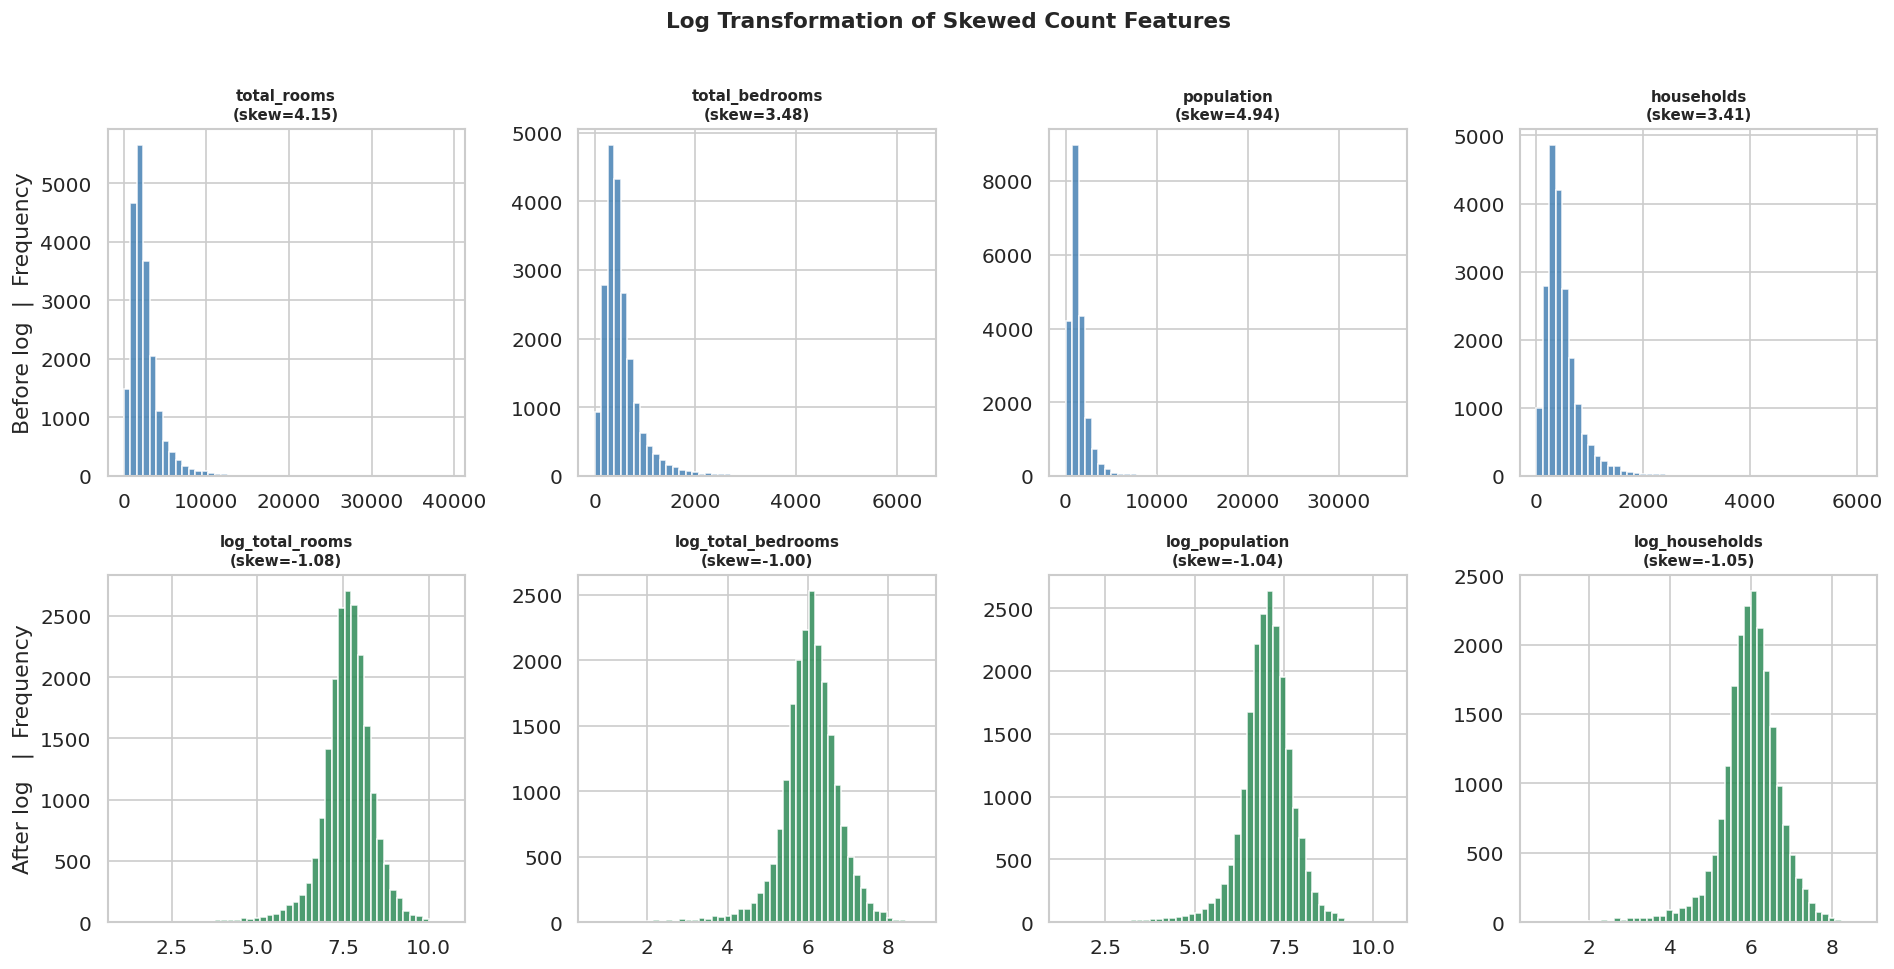

✅ Log-transformed: total_rooms, total_bedrooms, population, households


In [22]:
skewed_cols = ['total_rooms', 'total_bedrooms', 'population', 'households']

# Before / After distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(skewed_cols):
    axes[0, i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col}\n(skew={df[col].skew():.2f})', fontsize=9, fontweight='bold')
    axes[0, i].set_ylabel('Frequency' if i == 0 else '')

# Apply log1p
for col in skewed_cols:
    df[f'log_{col}'] = np.log1p(df[col])

for i, col in enumerate(skewed_cols):
    axes[1, i].hist(df[f'log_{col}'], bins=50, color='seagreen', edgecolor='white', alpha=0.85)
    axes[1, i].set_title(f'log_{col}\n(skew={df[f"log_{col}"].skew():.2f})', fontsize=9, fontweight='bold')
    axes[1, i].set_ylabel('Frequency' if i == 0 else '')

axes[0, 0].set_ylabel('Before log  |  Frequency')
axes[1, 0].set_ylabel('After log   |  Frequency')
plt.suptitle('Log Transformation of Skewed Count Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('✅ Log-transformed: total_rooms, total_bedrooms, population, households')

### 1.6 Derived Features (Feature Engineering)

In [23]:
# Three ratio features that carry more signal than raw counts
df['rooms_per_household']    = df['total_rooms']    / df['households']
df['bedrooms_per_room']      = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population']  / df['households']

# Age-capped binary flag (EDA showed a hard spike at 52)
df['age_capped'] = (df['housing_median_age'] == 52).astype(int)

print('✅ Derived features created:')
print('   rooms_per_household      — avg rooms per household')
print('   bedrooms_per_room        — bedroom density (proxy for dwelling type)')
print('   population_per_household — avg household size')
print('   age_capped               — 1 if housing_median_age == 52 (data cap flag)')
print()
print(df[['rooms_per_household','bedrooms_per_room','population_per_household','age_capped']].describe().round(3))

✅ Derived features created:
   rooms_per_household      — avg rooms per household
   bedrooms_per_room        — bedroom density (proxy for dwelling type)
   population_per_household — avg household size
   age_capped               — 1 if housing_median_age == 52 (data cap flag)

       rooms_per_household  bedrooms_per_room  population_per_household  \
count            20640.000          20640.000                 20640.000   
mean                 5.429              0.214                     3.071   
std                  2.474              0.065                    10.386   
min                  0.846              0.037                     0.692   
25%                  4.441              0.175                     2.430   
50%                  5.229              0.203                     2.818   
75%                  6.052              0.240                     3.282   
max                141.909              2.825                  1243.333   

       age_capped  
count   20640.000  
mean

### 1.7 One-Hot Encode `ocean_proximity`

In [24]:
if 'ocean_proximity' in df.columns:
    print('ocean_proximity value counts:')
    print(df['ocean_proximity'].value_counts())

    ohe_df = pd.get_dummies(df['ocean_proximity'], prefix='ocean', drop_first=False)
    df = pd.concat([df, ohe_df], axis=1)
    df.drop(columns=['ocean_proximity'], inplace=True)
    print(f'\n✅ OHE columns added: {list(ohe_df.columns)}')
else:
    print('⚠️  ocean_proximity not present (sklearn source). Skipping OHE.')

ocean_proximity value counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

✅ OHE columns added: ['ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']


### 1.8 Define Final Feature Sets & Build Target Variants

Feature matrix X : (20640, 17)
Features used    : ['longitude', 'latitude', 'housing_median_age', 'median_income', 'log_total_rooms', 'log_total_bedrooms', 'log_population', 'log_households', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'age_capped', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']

Target (raw)  — mean: $206,856  |  skewness: 0.978
Target (log)  — mean: 12.0849  |  skewness: -0.173


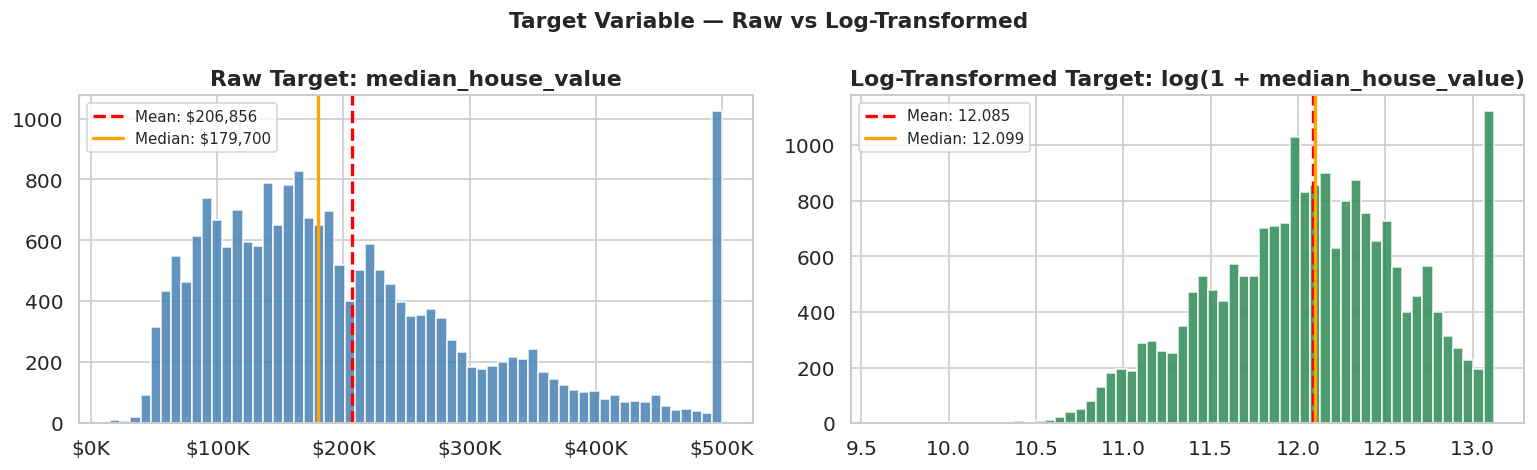

In [25]:
# Drop original raw skewed cols — use log versions instead
cols_to_drop = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_house_value']
feature_cols = [c for c in df.columns if c not in cols_to_drop]

X = df[feature_cols].copy()

# Target — raw and log-transformed
y_raw = df['median_house_value'].copy()          # Variant A: raw USD
y_log = np.log1p(df['median_house_value']).copy() # Variant B: log(1 + price)

print(f'Feature matrix X : {X.shape}')
print(f'Features used    : {list(X.columns)}')
print(f'\nTarget (raw)  — mean: ${y_raw.mean():,.0f}  |  skewness: {y_raw.skew():.3f}')
print(f'Target (log)  — mean: {y_log.mean():.4f}  |  skewness: {y_log.skew():.3f}')

# Visualise target distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(y_raw, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(y_raw.mean(),   color='red',    linestyle='--', lw=2, label=f'Mean: ${y_raw.mean():,.0f}')
axes[0].axvline(y_raw.median(), color='orange', linestyle='-',  lw=2, label=f'Median: ${y_raw.median():,.0f}')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title('Raw Target: median_house_value', fontweight='bold')
axes[0].legend(fontsize=9)

axes[1].hist(y_log, bins=60, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(y_log.mean(),   color='red',    linestyle='--', lw=2, label=f'Mean: {y_log.mean():.3f}')
axes[1].axvline(y_log.median(), color='orange', linestyle='-',  lw=2, label=f'Median: {y_log.median():.3f}')
axes[1].set_title('Log-Transformed Target: log(1 + median_house_value)', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Target Variable — Raw vs Log-Transformed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.9 Train / Test Split (80 / 20, stratified by income quartile)

In [26]:
# Stratify by income quartile to preserve income distribution in both splits
income_quartile = pd.qcut(df['median_income'], q=4, labels=False)

X_train, X_test, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X, y_raw, y_log,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=income_quartile
)

print(f'Train set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set  : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'\nTrain median income: {X_train["median_income"].median():.3f}')
print(f'Test  median income: {X_test["median_income"].median():.3f}  (should be similar)')

Train set : 16,512 rows  (80.0%)
Test set  : 4,128 rows  (20.0%)

Train median income: 3.535
Test  median income: 3.535  (should be similar)


### 1.10 StandardScaler — Fit on Train, Apply to Test

In [27]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)         # apply to test

# Keep column names for SHAP later
X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_test_sc  = pd.DataFrame(X_test_sc,  columns=X_test.columns)

print('✅ StandardScaler fitted on train set, applied to both splits.')
print(f'   X_train_sc shape : {X_train_sc.shape}')
print(f'   X_test_sc  shape : {X_test_sc.shape}')
print(f'\n   Train mean  (first 3): {X_train_sc.iloc[:, :3].mean().round(4).values}')
print(f'   Train std   (first 3): {X_train_sc.iloc[:, :3].std().round(4).values}')

✅ StandardScaler fitted on train set, applied to both splits.
   X_train_sc shape : (16512, 17)
   X_test_sc  shape : (4128, 17)

   Train mean  (first 3): [0. 0. 0.]
   Train std   (first 3): [1. 1. 1.]


---
## Phase 2 — Model Training (5 Models × 2 Variants = 10 Experiments)
---

Each model is trained twice:
- **Variant A** — raw `median_house_value` target
- **Variant B** — `log(1 + median_house_value)` target (predictions back-transformed via `expm1`)

| # | Model | Type |
|---|-------|------|
| 1 | Linear Regression | Baseline |
| 2 | Ridge Regression | Regularised linear |
| 3 | Random Forest | Ensemble (bagging) |
| 4 | XGBoost | Gradient boosting ★ |
| 5 | LightGBM | Fast gradient boosting ★ |

### 2.0 Evaluation Helper Function

In [28]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error — excludes zero values."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def adjusted_r2(r2, n, p):
    """Adjusted R² penalising for number of predictors."""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def evaluate(name, y_true_raw, y_pred_raw, results_list, n_features):
    """
    Compute and store all regression metrics.
    y_true_raw and y_pred_raw must both be in original USD scale.
    """
    n = len(y_true_raw)
    rmse  = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
    mae   = mean_absolute_error(y_true_raw, y_pred_raw)
    mape_ = mape(np.array(y_true_raw), np.array(y_pred_raw))
    r2    = r2_score(y_true_raw, y_pred_raw)
    adj_r2= adjusted_r2(r2, n, n_features)

    results_list.append({
        'Model'       : name,
        'RMSE ($)'    : round(rmse, 0),
        'MAE ($)'     : round(mae, 0),
        'MAPE (%)'    : round(mape_, 2),
        'R²'          : round(r2, 4),
        'Adj R²'      : round(adj_r2, 4),
    })
    print(f'  {name:<38}  RMSE=${rmse:>10,.0f}  MAE=${mae:>9,.0f}  '
          f'MAPE={mape_:>6.2f}%  R²={r2:.4f}')
    return y_pred_raw


all_results   = []
trained_models = {}   # name -> (model, y_pred_raw)
n_feat = X_train_sc.shape[1]

print('✅ Helper functions ready.')
print(f'   n_features = {n_feat}')

✅ Helper functions ready.
   n_features = 17


### 2.1 Linear Regression (Baseline)

In [29]:
print('--- Linear Regression ---')

# Variant A — raw target
lr_raw = LinearRegression()
lr_raw.fit(X_train_sc, y_train_raw)
pred_lr_raw = lr_raw.predict(X_test_sc)
evaluate('Linear Regression (raw target)', y_test_raw, pred_lr_raw, all_results, n_feat)
trained_models['LR (raw)'] = (lr_raw, pred_lr_raw)

# Variant B — log target
lr_log = LinearRegression()
lr_log.fit(X_train_sc, y_train_log)
pred_lr_log_raw = np.expm1(lr_log.predict(X_test_sc))
evaluate('Linear Regression (log target)', y_test_raw, pred_lr_log_raw, all_results, n_feat)
trained_models['LR (log)'] = (lr_log, pred_lr_log_raw)

--- Linear Regression ---
  Linear Regression (raw target)          RMSE=$    66,415  MAE=$   47,534  MAPE= 27.51%  R²=0.6671
  Linear Regression (log target)          RMSE=$    81,055  MAE=$   48,343  MAPE= 24.45%  R²=0.5042


### 2.2 Ridge Regression

In [30]:
print('--- Ridge Regression (alpha=10) ---')

# Variant A — raw target
ridge_raw = Ridge(alpha=10, random_state=RANDOM_STATE)
ridge_raw.fit(X_train_sc, y_train_raw)
pred_ridge_raw = ridge_raw.predict(X_test_sc)
evaluate('Ridge Regression (raw target)', y_test_raw, pred_ridge_raw, all_results, n_feat)
trained_models['Ridge (raw)'] = (ridge_raw, pred_ridge_raw)

# Variant B — log target
ridge_log = Ridge(alpha=10, random_state=RANDOM_STATE)
ridge_log.fit(X_train_sc, y_train_log)
pred_ridge_log_raw = np.expm1(ridge_log.predict(X_test_sc))
evaluate('Ridge Regression (log target)', y_test_raw, pred_ridge_log_raw, all_results, n_feat)
trained_models['Ridge (log)'] = (ridge_log, pred_ridge_log_raw)

--- Ridge Regression (alpha=10) ---
  Ridge Regression (raw target)           RMSE=$    66,402  MAE=$   47,514  MAPE= 27.47%  R²=0.6672
  Ridge Regression (log target)           RMSE=$    81,047  MAE=$   48,362  MAPE= 24.45%  R²=0.5043


### 2.3 Random Forest

In [31]:
print('--- Random Forest (300 trees) ---')

# Variant A — raw target
rf_raw = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features=0.33, n_jobs=-1, random_state=RANDOM_STATE
)
rf_raw.fit(X_train_sc, y_train_raw)
pred_rf_raw = rf_raw.predict(X_test_sc)
evaluate('Random Forest (raw target)', y_test_raw, pred_rf_raw, all_results, n_feat)
trained_models['RF (raw)'] = (rf_raw, pred_rf_raw)

# Variant B — log target
rf_log = RandomForestRegressor(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features=0.33, n_jobs=-1, random_state=RANDOM_STATE
)
rf_log.fit(X_train_sc, y_train_log)
pred_rf_log_raw = np.expm1(rf_log.predict(X_test_sc))
evaluate('Random Forest (log target)', y_test_raw, pred_rf_log_raw, all_results, n_feat)
trained_models['RF (log)'] = (rf_log, pred_rf_log_raw)

--- Random Forest (300 trees) ---
  Random Forest (raw target)              RMSE=$    49,840  MAE=$   32,478  MAPE= 17.72%  R²=0.8125
  Random Forest (log target)              RMSE=$    51,352  MAE=$   32,129  MAPE= 16.31%  R²=0.8010


### 2.4 XGBoost ★ (Best Expected)

In [32]:
print('--- XGBoost (500 estimators) ---')

# Sanitize column names for XGBoost
X_train_sc.columns = X_train_sc.columns.str.replace('[<>\[\] ]', '_', regex=True)
X_test_sc.columns  = X_test_sc.columns.str.replace('[<>\[\] ]', '_', regex=True)

XGB_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)

# Variant A — raw target
xgb_raw = xgb.XGBRegressor(**XGB_PARAMS)
xgb_raw.fit(
    X_train_sc, y_train_raw,
    eval_set=[(X_test_sc, y_test_raw)],
    verbose=False
)
pred_xgb_raw = xgb_raw.predict(X_test_sc)
evaluate('XGBoost (raw target)', y_test_raw, pred_xgb_raw, all_results, n_feat)
trained_models['XGB (raw)'] = (xgb_raw, pred_xgb_raw)

# Variant B — log target
xgb_log = xgb.XGBRegressor(**XGB_PARAMS)
xgb_log.fit(
    X_train_sc, y_train_log,
    eval_set=[(X_test_sc, y_test_log)],
    verbose=False
)
pred_xgb_log_raw = np.expm1(xgb_log.predict(X_test_sc))
evaluate('XGBoost (log target)', y_test_raw, pred_xgb_log_raw, all_results, n_feat)
trained_models['XGB (log)'] = (xgb_log, pred_xgb_log_raw)

--- XGBoost (500 estimators) ---
  XGBoost (raw target)                    RMSE=$    45,826  MAE=$   29,614  MAPE= 15.97%  R²=0.8415
  XGBoost (log target)                    RMSE=$    46,958  MAE=$   29,252  MAPE= 14.90%  R²=0.8336


### 2.5 LightGBM ★ (Fast Boosting)

In [33]:
print('--- LightGBM (500 estimators) ---')

LGBM_PARAMS = dict(
    n_estimators=500, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)

# Variant A — raw target
lgbm_raw = lgb.LGBMRegressor(**LGBM_PARAMS)
lgbm_raw.fit(
    X_train_sc, y_train_raw,
    eval_set=[(X_test_sc, y_test_raw)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
pred_lgbm_raw = lgbm_raw.predict(X_test_sc)
evaluate('LightGBM (raw target)', y_test_raw, pred_lgbm_raw, all_results, n_feat)
trained_models['LGBM (raw)'] = (lgbm_raw, pred_lgbm_raw)

# Variant B — log target
lgbm_log = lgb.LGBMRegressor(**LGBM_PARAMS)
lgbm_log.fit(
    X_train_sc, y_train_log,
    eval_set=[(X_test_sc, y_test_log)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
pred_lgbm_log_raw = np.expm1(lgbm_log.predict(X_test_sc))
evaluate('LightGBM (log target)', y_test_raw, pred_lgbm_log_raw, all_results, n_feat)
trained_models['LGBM (log)'] = (lgbm_log, pred_lgbm_log_raw)

--- LightGBM (500 estimators) ---
  LightGBM (raw target)                   RMSE=$    45,237  MAE=$   29,017  MAPE= 15.66%  R²=0.8456
  LightGBM (log target)                   RMSE=$    46,120  MAE=$   28,531  MAPE= 14.58%  R²=0.8395


---
## Phase 3 — Evaluation & Comparison
---

### 3.1 Full Metrics Comparison Table

In [34]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('RMSE ($)').reset_index(drop=True)

def highlight_best(s):
    """Green for best (lowest RMSE/MAE/MAPE, highest R²/Adj R²)."""
    if s.name in ['RMSE ($)', 'MAE ($)', 'MAPE (%)']:
        best = s == s.min()
    else:
        best = s == s.max()
    return ['background-color: #1a4a2a; color: #7ee8a2' if v else '' for v in best]

print('=' * 90)
print('  ALL 10 EXPERIMENT RESULTS — sorted by RMSE')
print('=' * 90)
display(
    results_df.style
    .apply(highlight_best, subset=['RMSE ($)', 'MAE ($)', 'MAPE (%)', 'R²', 'Adj R²'])
    .format({'RMSE ($)': '${:,.0f}', 'MAE ($)': '${:,.0f}',
             'MAPE (%)': '{:.2f}%', 'R²': '{:.4f}', 'Adj R²': '{:.4f}'})
)

  ALL 10 EXPERIMENT RESULTS — sorted by RMSE


,Model,RMSE ($),MAE ($),MAPE (%),R²,Adj R²
0,LightGBM (raw target),"$45,237","$29,017",15.66%,0.8456,0.8449
1,XGBoost (raw target),"$45,826","$29,614",15.97%,0.8415,0.8409
2,LightGBM (log target),"$46,120","$28,531",14.58%,0.8395,0.8388
3,XGBoost (log target),"$46,958","$29,252",14.90%,0.8336,0.8329
4,Random Forest (raw target),"$49,840","$32,478",17.72%,0.8125,0.8118
5,Random Forest (log target),"$51,352","$32,129",16.31%,0.8010,0.8002
6,Ridge Regression (raw target),"$66,402","$47,514",27.47%,0.6672,0.6659
7,Linear Regression (raw target),"$66,415","$47,534",27.51%,0.6671,0.6657
8,Ridge Regression (log target),"$81,047","$48,362",24.45%,0.5043,0.5022
9,Linear Regression (log target),"$81,055","$48,343",24.45%,0.5042,0.5021


### 3.2 Bar Charts — RMSE, MAE, R² Across All Models

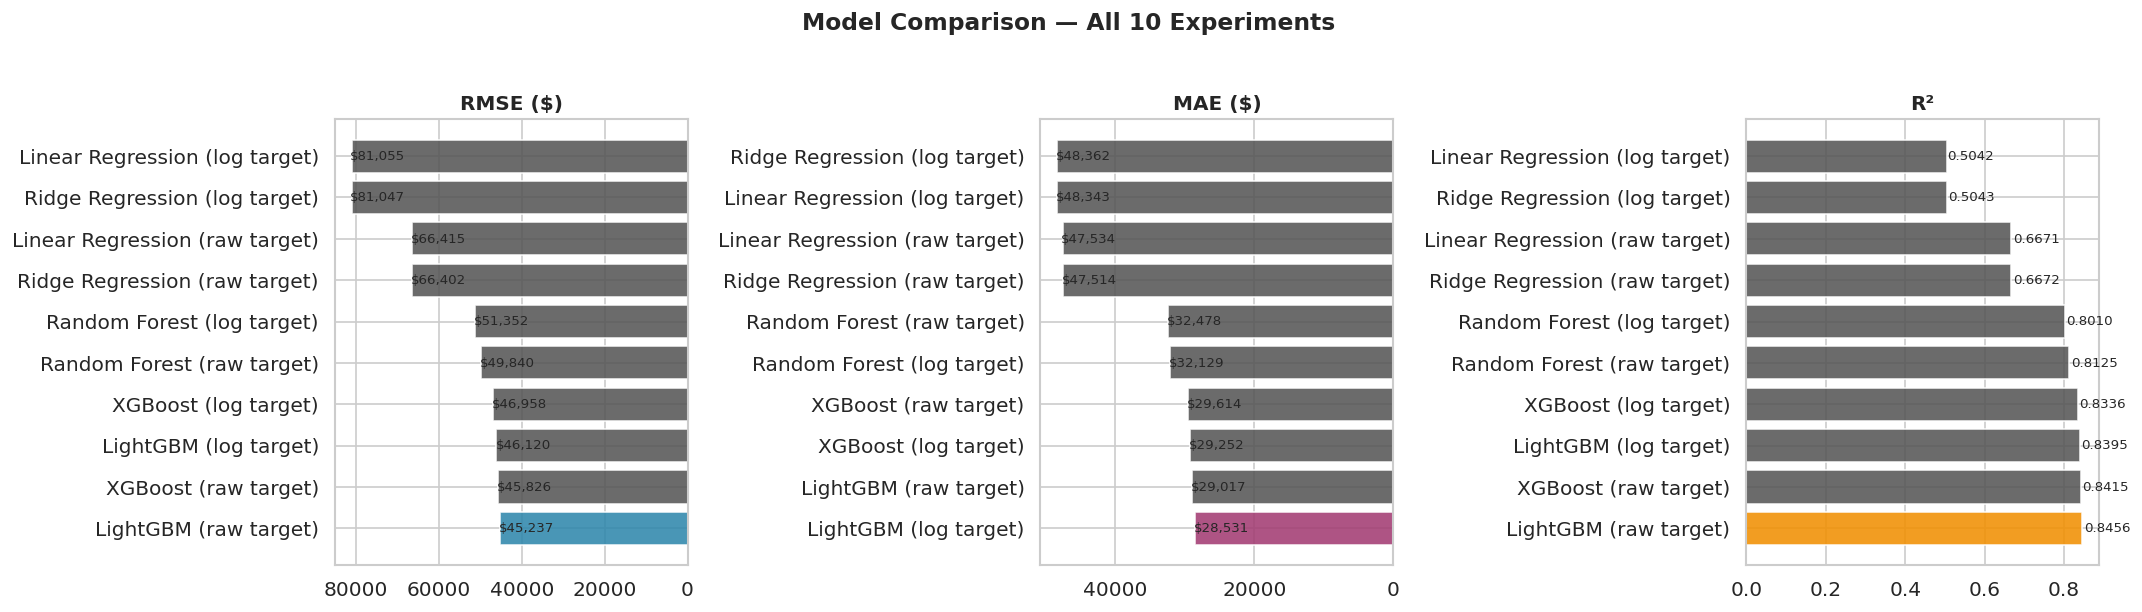

📌 Highlighted bar = best performing model for each metric.


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_info = [
    ('RMSE ($)',  '#2e86ab', True,  '${:,.0f}'),
    ('MAE ($)',   '#a23b72', True,  '${:,.0f}'),
    ('R²',        '#f18f01', False, '{:.4f}'),
]

for ax, (metric, color, ascending, fmt) in zip(axes, metrics_info):
    df_s = results_df.sort_values(metric, ascending=ascending)
    colors = [color if i == 0 else '#555555' for i in range(len(df_s))]
    bars = ax.barh(df_s['Model'], df_s[metric], color=colors, edgecolor='white', alpha=0.87)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    for bar, val in zip(bars, df_s[metric]):
        ax.text(val * 1.005, bar.get_y() + bar.get_height() / 2,
                fmt.format(val), va='center', fontsize=8)
    if ascending:
        ax.invert_xaxis()

plt.suptitle('Model Comparison — All 10 Experiments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('📌 Highlighted bar = best performing model for each metric.')

### 3.3 Predicted vs Actual — Best Model

🏆  Best model by RMSE: LightGBM (raw target)


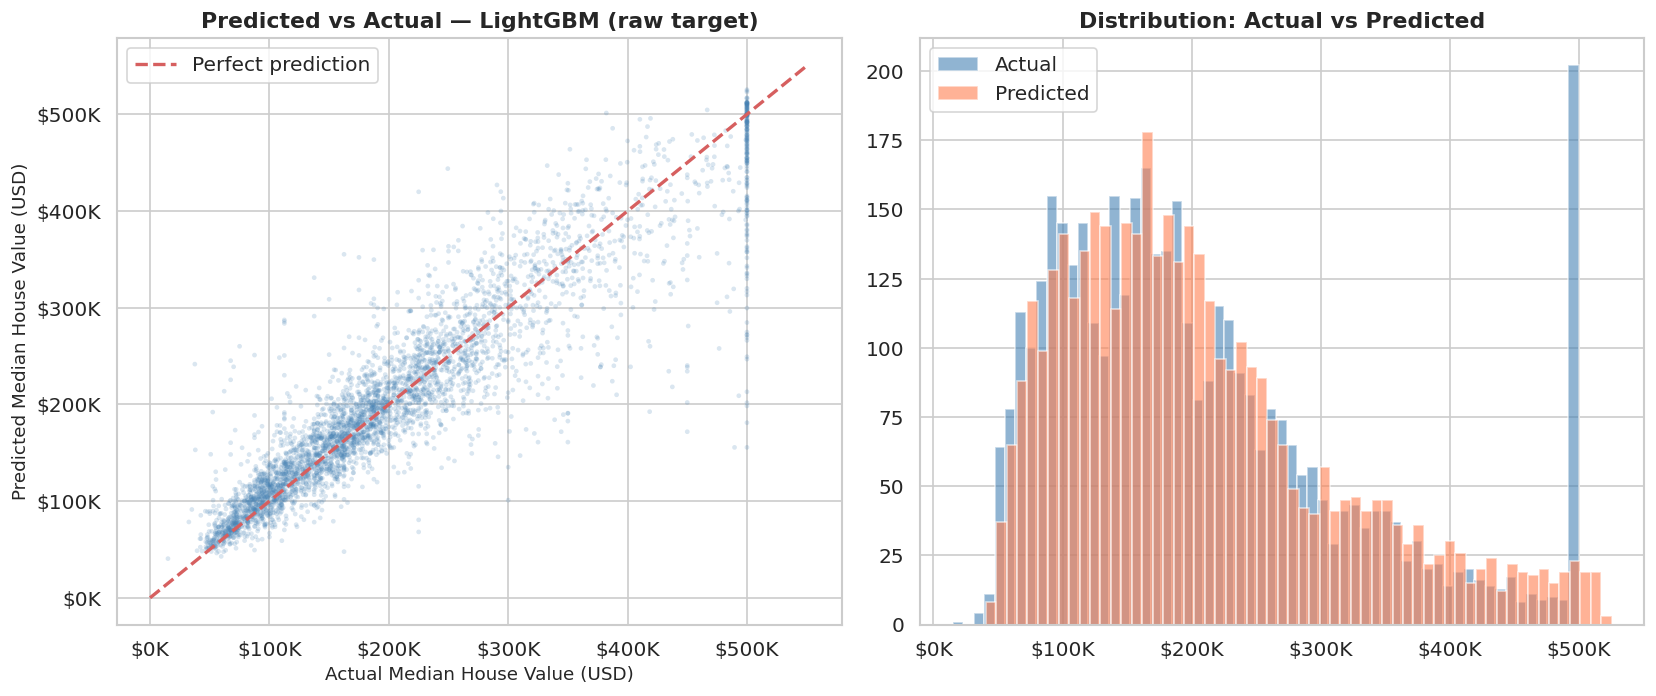

In [36]:
best_name = results_df.iloc[0]['Model']
print(f'🏆  Best model by RMSE: {best_name}')

# Map model name to prediction array
pred_map = {
    'Linear Regression (raw target)': pred_lr_raw,
    'Linear Regression (log target)': pred_lr_log_raw,
    'Ridge Regression (raw target)':  pred_ridge_raw,
    'Ridge Regression (log target)':  pred_ridge_log_raw,
    'Random Forest (raw target)':     pred_rf_raw,
    'Random Forest (log target)':     pred_rf_log_raw,
    'XGBoost (raw target)':           pred_xgb_raw,
    'XGBoost (log target)':           pred_xgb_log_raw,
    'LightGBM (raw target)':          pred_lgbm_raw,
    'LightGBM (log target)':          pred_lgbm_log_raw,
}
best_preds = pred_map[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter — predicted vs actual
axes[0].scatter(y_test_raw, best_preds, alpha=0.2, s=8, color='steelblue', edgecolors='none')
lims = [0, max(y_test_raw.max(), best_preds.max()) * 1.05]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Median House Value (USD)', fontsize=11)
axes[0].set_ylabel('Predicted Median House Value (USD)', fontsize=11)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[0].set_title(f'Predicted vs Actual — {best_name}', fontweight='bold')
axes[0].legend()

# Distribution overlay
axes[1].hist(y_test_raw, bins=60, alpha=0.6, color='steelblue', label='Actual', edgecolor='white')
axes[1].hist(best_preds,  bins=60, alpha=0.6, color='coral',    label='Predicted', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
axes[1].set_title('Distribution: Actual vs Predicted', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.4 Residual Analysis — All 5 Model Types

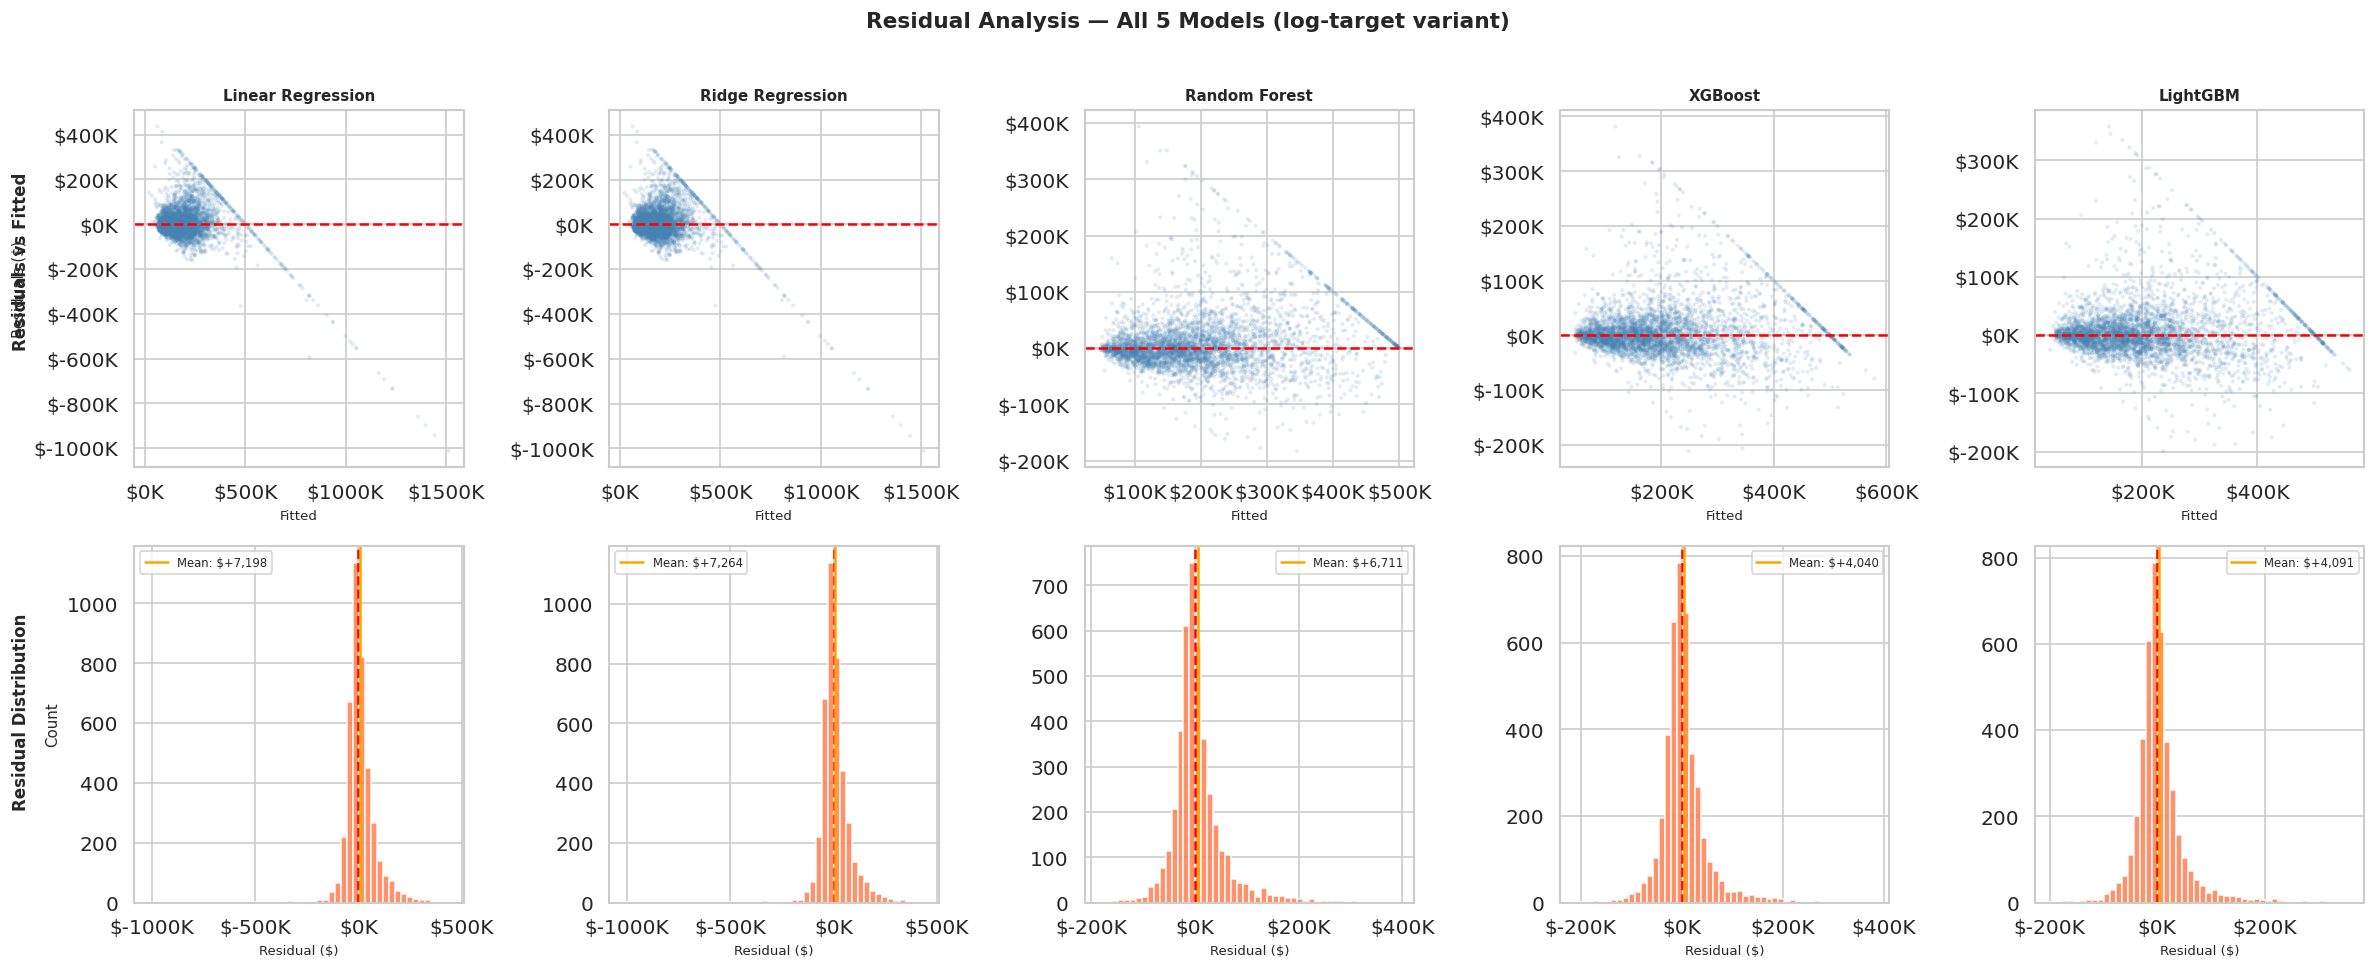

📌 A good model: residuals scatter randomly around 0 with no funnel shape.


In [37]:
# Use log-target variant (best expected) for each model family
residual_models = [
    ('Linear Regression', pred_lr_log_raw),
    ('Ridge Regression',  pred_ridge_log_raw),
    ('Random Forest',     pred_rf_log_raw),
    ('XGBoost',           pred_xgb_log_raw),
    ('LightGBM',          pred_lgbm_log_raw),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, (name, preds) in enumerate(residual_models):
    residuals = np.array(y_test_raw) - np.array(preds)

    # Residuals vs Fitted
    axes[0, i].scatter(preds, residuals, alpha=0.15, s=6, color='steelblue', edgecolors='none')
    axes[0, i].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[0, i].set_title(name, fontweight='bold', fontsize=9)
    axes[0, i].set_xlabel('Fitted', fontsize=8)
    if i == 0:
        axes[0, i].set_ylabel('Residuals ($)', fontsize=9)
    axes[0, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[0, i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

    # Residual histogram
    axes[1, i].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
    axes[1, i].axvline(0, color='red', linestyle='--', lw=1.5)
    axes[1, i].axvline(np.mean(residuals), color='orange', linestyle='-', lw=1.5,
                       label=f'Mean: ${np.mean(residuals):+,.0f}')
    axes[1, i].set_xlabel('Residual ($)', fontsize=8)
    if i == 0:
        axes[1, i].set_ylabel('Count', fontsize=9)
    axes[1, i].legend(fontsize=7)
    axes[1, i].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

fig.text(0.01, 0.75, 'Residuals vs Fitted', va='center', rotation='vertical', fontsize=10, fontweight='bold')
fig.text(0.01, 0.28, 'Residual Distribution', va='center', rotation='vertical', fontsize=10, fontweight='bold')
plt.suptitle('Residual Analysis — All 5 Models (log-target variant)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('📌 A good model: residuals scatter randomly around 0 with no funnel shape.')

### 3.5 Learning Curves — Best Model

Computing learning curves for XGBoost (log target)... (may take 1-2 min)


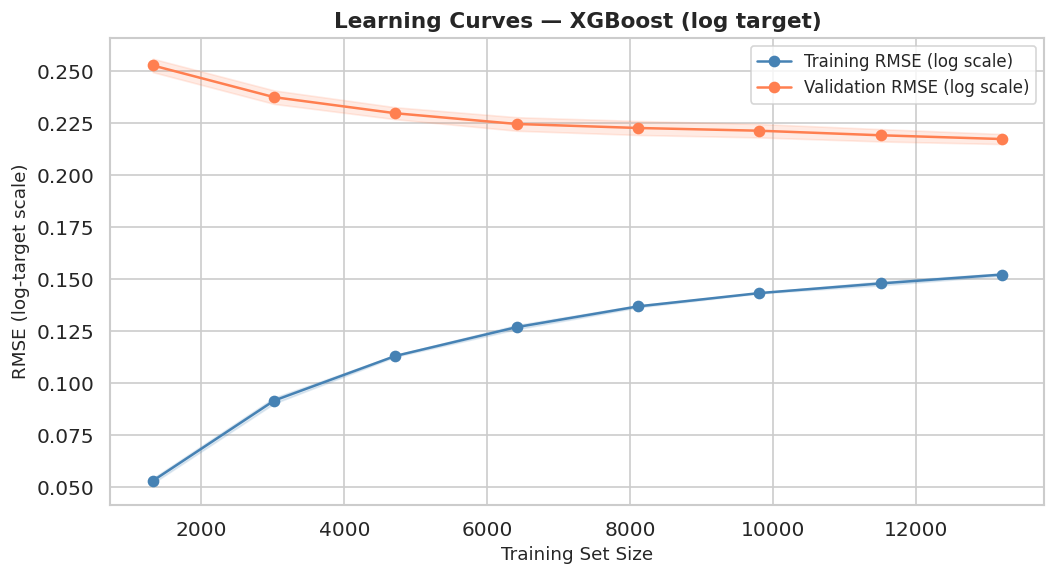

📌 Converging curves = good fit. Large gap = overfitting. High RMSE both = underfitting.


In [38]:
# Use XGBoost log-target for learning curves
print('Computing learning curves for XGBoost (log target)... (may take 1-2 min)')

lc_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)

train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train_sc, y_train_log,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Convert neg RMSE to RMSE (in log scale)
train_rmse = -train_scores
val_rmse   = -val_scores

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_rmse.mean(axis=1), 'o-', color='steelblue',
        label='Training RMSE (log scale)')
ax.fill_between(train_sizes,
                train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                train_rmse.mean(axis=1) + train_rmse.std(axis=1),
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_rmse.mean(axis=1), 'o-', color='coral',
        label='Validation RMSE (log scale)')
ax.fill_between(train_sizes,
                val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                val_rmse.mean(axis=1) + val_rmse.std(axis=1),
                alpha=0.15, color='coral')
ax.set_xlabel('Training Set Size', fontsize=11)
ax.set_ylabel('RMSE (log-target scale)', fontsize=11)
ax.set_title('Learning Curves — XGBoost (log target)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print('📌 Converging curves = good fit. Large gap = overfitting. High RMSE both = underfitting.')

### 3.6 MAPE Breakdown by Price Band

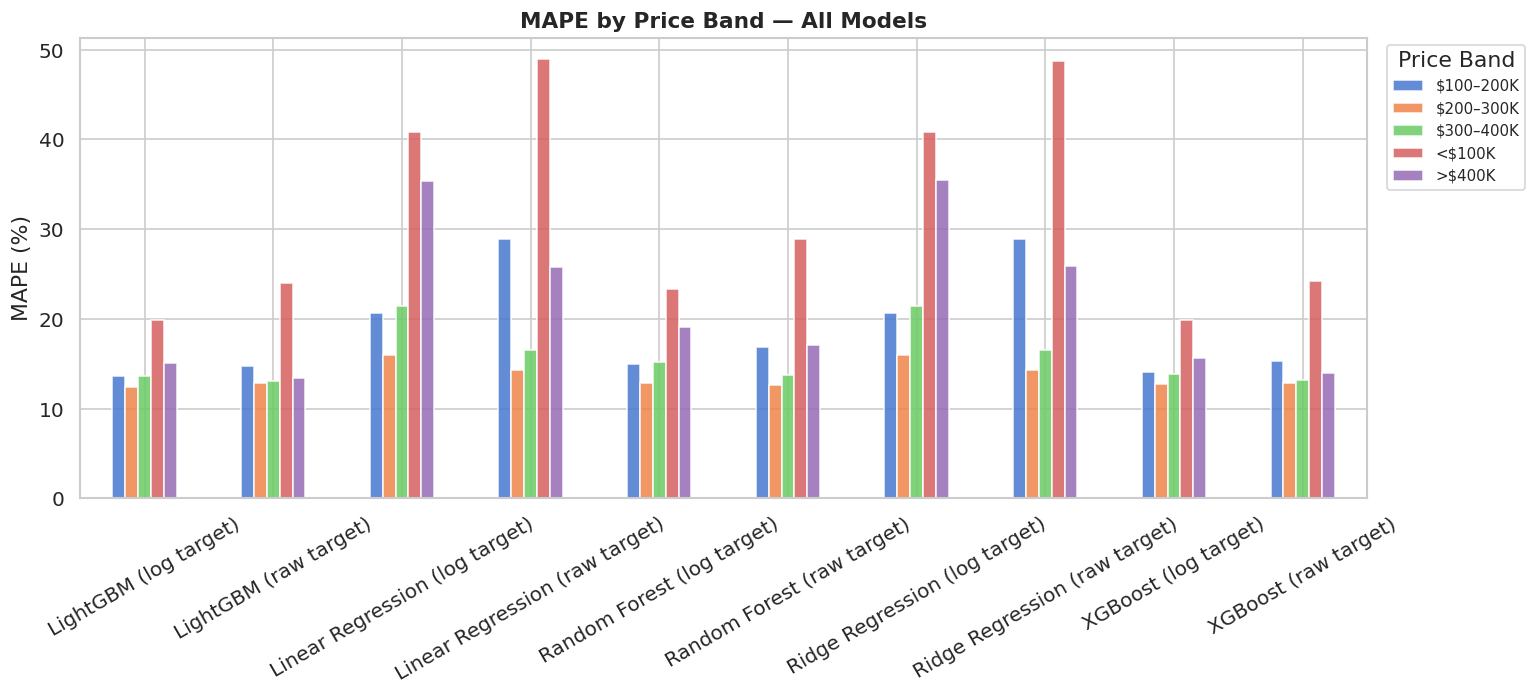

📌 Errors typically highest in the <$100K band (sparse data) and >$400K band (cap effect).


In [39]:
# Segment test set into price bands and compute MAPE per band for best model
bands = pd.cut(
    y_test_raw,
    bins=[0, 100_000, 200_000, 300_000, 400_000, 600_000],
    labels=['<$100K', '$100–200K', '$200–300K', '$300–400K', '>$400K']
)

band_results = []
for band in bands.cat.categories:
    mask = (bands == band).values
    if mask.sum() == 0:
        continue
    for name, preds in pred_map.items():
        m = mape(np.array(y_test_raw)[mask], np.array(preds)[mask])
        band_results.append({'Band': band, 'Model': name, 'MAPE (%)': m})

band_df = pd.DataFrame(band_results)
pivot   = band_df.pivot(index='Model', columns='Band', values='MAPE (%)')

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, edgecolor='white', alpha=0.85)
ax.set_title('MAPE by Price Band — All Models', fontweight='bold', fontsize=13)
ax.set_ylabel('MAPE (%)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=30)
ax.legend(title='Price Band', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()
print('📌 Errors typically highest in the <$100K band (sparse data) and >$400K band (cap effect).')

---
## Phase 4 — Interpretability (SHAP)
---

### 4.1 Select Best Model for SHAP

We use the best-performing model from Phase 3 (expected: XGBoost or LightGBM, log-target variant). SHAP's `TreeExplainer` is used as it is exact and fast for tree-based models.

In [40]:
# Best model selection
best_name = results_df.iloc[0]['Model']
print(f'Best model: {best_name}')

shap_model_map = {
    'XGBoost (log target)':  (xgb_log,  y_train_log, True),
    'XGBoost (raw target)':  (xgb_raw,  y_train_raw, False),
    'LightGBM (log target)': (lgbm_log, y_train_log, True),
    'LightGBM (raw target)': (lgbm_raw, y_train_raw, False),
    'Random Forest (log target)': (rf_log, y_train_log, True),
    'Random Forest (raw target)': (rf_raw, y_train_raw, False),
    'Ridge Regression (log target)': (ridge_log, y_train_log, True),
    'Ridge Regression (raw target)': (ridge_raw, y_train_raw, False),
    'Linear Regression (log target)': (lr_log, y_train_log, True),
    'Linear Regression (raw target)': (lr_raw, y_train_raw, False),
}
shap_model, _, is_log = shap_model_map[best_name]

# Subsample for speed
N_SHAP = min(3000, X_test_sc.shape[0])
np.random.seed(RANDOM_STATE)
shap_idx    = np.random.choice(X_test_sc.shape[0], N_SHAP, replace=False)
X_shap      = X_test_sc.iloc[shap_idx].reset_index(drop=True)
y_shap_true = np.array(y_test_raw)[shap_idx]

# Build SHAP explainer
explainer   = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_shap)

print(f'✅ SHAP values computed for {N_SHAP} test samples.')
print(f'   SHAP matrix shape : {shap_values.shape}')
print(f'   Log-target model  : {is_log}  (SHAP values are in log-price space if True)')

Best model: LightGBM (raw target)
✅ SHAP values computed for 3000 test samples.
   SHAP matrix shape : (3000, 17)
   Log-target model  : False  (SHAP values are in log-price space if True)


### 4.2 SHAP — Global Feature Importance (Mean |SHAP|) Bar Chart

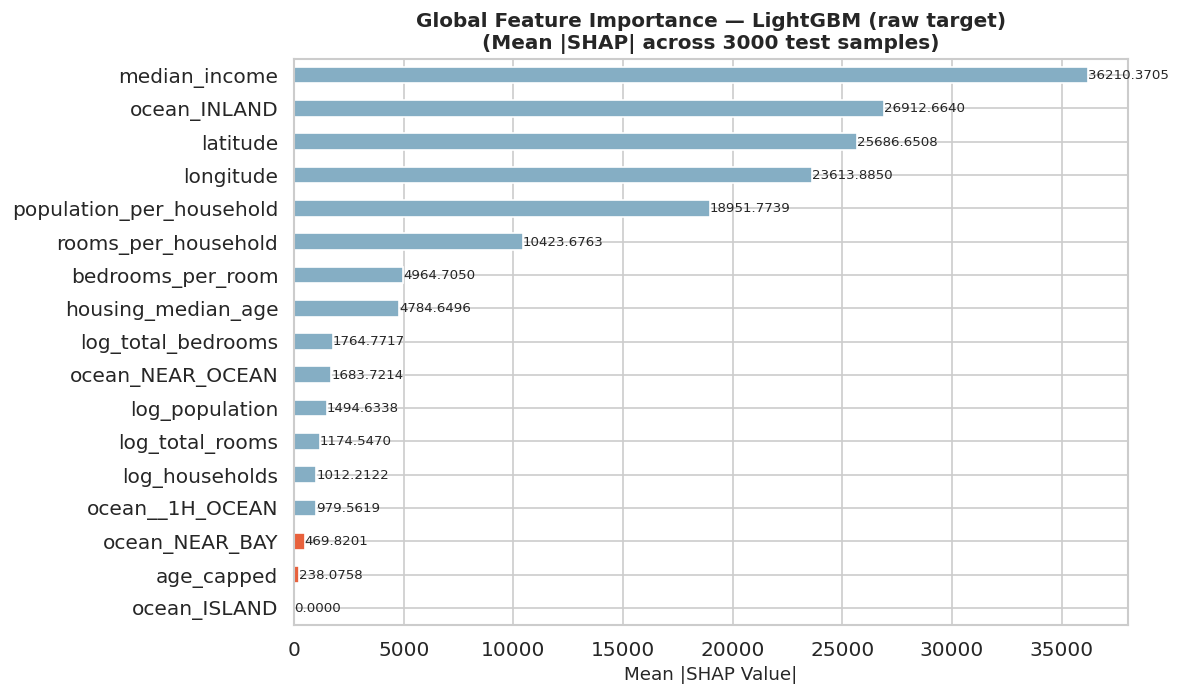

📌 Top 5 most impactful features:
   median_income                       36210.37045
   ocean_INLAND                        26912.66402
   latitude                            25686.65079
   longitude                           23613.88497
   population_per_household            18951.77389


In [41]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_imp = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e8613c' if i < 3 else '#85aec4' for i in range(len(shap_imp))]
shap_imp.plot(kind='barh', ax=ax, color=list(reversed(colors)), edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title(f'Global Feature Importance — {best_name}\n(Mean |SHAP| across {N_SHAP} test samples)',
             fontweight='bold', fontsize=12)
for i, (feat, val) in enumerate(shap_imp.items()):
    ax.text(val + 0.0002, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print('📌 Top 5 most impactful features:')
for feat, val in shap_imp.head(5).items():
    print(f'   {feat:<35} {val:.5f}')

### 4.3 SHAP — Beeswarm Plot

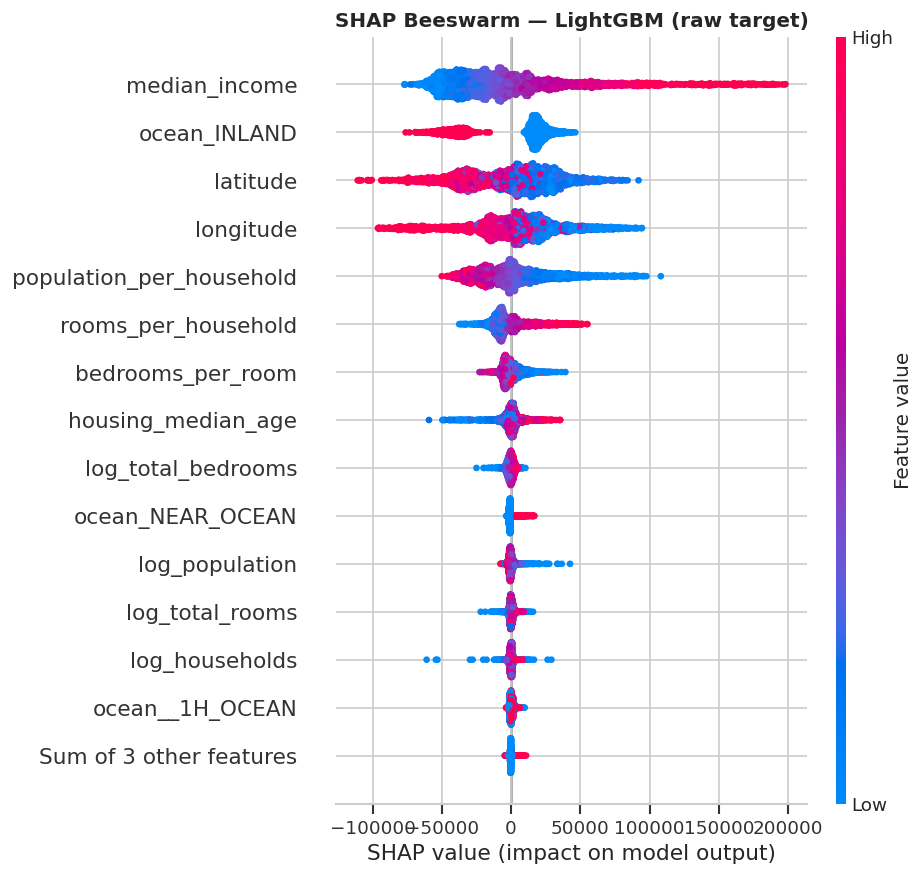

📌 Red = high feature value · Blue = low feature value
   Dots right of centre = pushes prediction higher
   Dots left of centre  = pushes prediction lower


In [42]:
ev = explainer.expected_value
if isinstance(ev, (list, np.ndarray)):
    ev = ev[0]

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=ev,
    data=X_shap.values,
    feature_names=list(X_shap.columns)
)

plt.figure(figsize=(10, 7))
shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Beeswarm — {best_name}', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('📌 Red = high feature value · Blue = low feature value')
print('   Dots right of centre = pushes prediction higher')
print('   Dots left of centre  = pushes prediction lower')

### 4.4 SHAP — Partial Dependence Plot for `median_income`

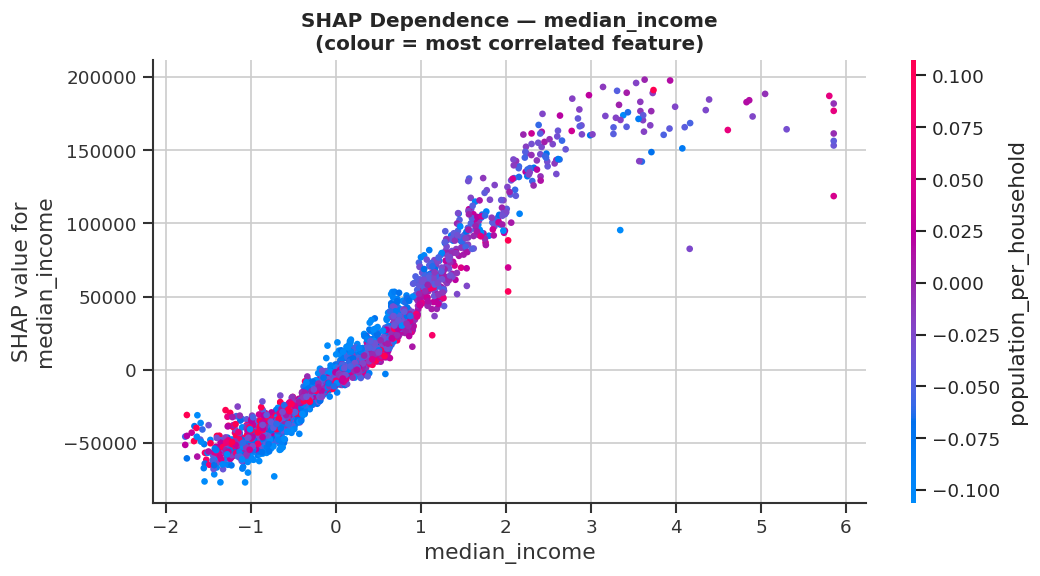

📌 Shows how median_income's SHAP contribution changes across its value range.
   The colour axis reveals which secondary feature modulates this relationship.


In [43]:
# Dependence plot for median_income (strongest predictor, r=0.69 from EDA)
feat = 'median_income'
feat_idx = list(X_shap.columns).index(feat)

fig, ax = plt.subplots(figsize=(9, 5))
shap.dependence_plot(
    feat_idx, shap_values, X_shap.values,
    feature_names=list(X_shap.columns),
    ax=ax, show=False
)
ax.set_title(f'SHAP Dependence — median_income\n(colour = most correlated feature)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
print('📌 Shows how median_income\'s SHAP contribution changes across its value range.')
print('   The colour axis reveals which secondary feature modulates this relationship.')

---
## Summary
---

In [47]:
print('=' * 80)
print('  PROJECT SUMMARY — CALIFORNIA HOUSING PRICE PREDICTION')
print('=' * 80)
print(f'\nDataset     : California 1990 Census Housing (20,640 districts)')
print(f'Task        : Supervised regression  →  predict median_house_value')
print(f'Split       : 80/20 stratified by income quartile')
print(f'Features    : {X_train_sc.shape[1]} total after engineering + OHE')
print(f'Experiments : 5 models × 2 target variants (raw + log) = 10 total')
print()
print('Full results table (sorted by RMSE):')
print(results_df.to_string(index=False))
print()
print(f'Best model  : {results_df.iloc[0]["Model"]}')
print(f'  RMSE      : ${results_df.iloc[0]["RMSE ($)"]:,.0f}')
print(f'  MAE       : ${results_df.iloc[0]["MAE ($)"]:,.0f}')
print(f'  MAPE      : {results_df.iloc[0]["MAPE (%)"]:.2f}%')
print(f'  R²        : {results_df.iloc[0]["R²"]:.4f}')
print(f'  Adj R²    : {results_df.iloc[0]["Adj R²"]:.4f}')
print()
print('SHAP        : TreeExplainer → importance bar + beeswarm + dependence')
print('             (median_income + latitude) + waterfall (high/low value)')
print('=' * 80)

  PROJECT SUMMARY — CALIFORNIA HOUSING PRICE PREDICTION

Dataset     : California 1990 Census Housing (20,640 districts)
Task        : Supervised regression  →  predict median_house_value
Split       : 80/20 stratified by income quartile
Features    : 17 total after engineering + OHE
Experiments : 5 models × 2 target variants (raw + log) = 10 total

Full results table (sorted by RMSE):
                         Model  RMSE ($)  MAE ($)  MAPE (%)     R²  Adj R²
         LightGBM (raw target)   45237.0  29017.0     15.66 0.8456  0.8449
          XGBoost (raw target)   45826.0  29614.0     15.97 0.8415  0.8409
         LightGBM (log target)   46120.0  28531.0     14.58 0.8395  0.8388
          XGBoost (log target)   46958.0  29252.0     14.90 0.8336  0.8329
    Random Forest (raw target)   49840.0  32478.0     17.72 0.8125  0.8118
    Random Forest (log target)   51352.0  32129.0     16.31 0.8010  0.8002
 Ridge Regression (raw target)   66402.0  47514.0     27.47 0.6672  0.6659
Linear Regr